## 영역 M (Modeling) audit 적용 노트북
- 적용 대상 finding: Critical-1, A-M1, B-M3, B-M5, [D-008 fix] SMOTE 제거, 한글 폰트.
- 사용자 결정 외 finding(A-M2/A-M3/A-M4/B-M1/B-M2/B-M4/C-M1, Critical-2/Critical-3)은 코드 수정 없이 보고서 한계점으로 서술한다.
- 본 노트북은 식약처 담당자가 변경 사유를 추적할 수 있도록, 각 핵심 코드 셀 앞에 변경 사유 마크다운을 함께 둔다.


In [1]:
# === [DEFECT-014/015 fix] TF 결정성 환경변수 (반드시 tensorflow import 이전) ===
import os
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import pandas as pd

# === 한글 폰트 적용 (영역 M 추가, 영역 E의 font_helper 우선 사용) ===
try:
    from font_helper import setup_korean_font
    setup_korean_font()
except Exception:
    import matplotlib.pyplot as plt
    import platform
    _system = platform.system()
    if _system == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif _system == 'Darwin':
        plt.rcParams['font.family'] = 'AppleGothic'
    else:
        plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    print(f"[font] Korean font set inline (system={_system}, font={plt.rcParams['font.family']})")

# 프로젝트 기준 경로 설정
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))

path = os.path.join(BASE_DIR, 'df_enhanced.pkl.gz')
df = pd.read_pickle(path, compression='gzip')


[font_helper] 한글 폰트 적용: NanumGothic (axes.unicode_minus=False)


In [2]:
df['INSPCT_PURPS_NAME'].value_counts().reset_index().rename(columns={'index': 'INSPCT_PURPS_NAME', 'count': '개수'})

,INSPCT_PURPS_NAME,개수
0,자가품질위탁검사,61028
1,수거검사,17198
2,기타,1794
3,품질검사,681
4,제조.수입품목허가(신고)용검사,99
5,모니터링검사,70
6,허가.인증 신청 및 신고 검사,7
7,검사명령검사,3
8,압·몰수품검사,3


In [3]:
df

,INSPCT_PURPS_NAME,PRDLST_NM,사용주소,x_coord,y_coord,tmprt_150_59,tmprt_150Top_59,tmprt_150Lwet_59,hd_150_59,arvlty_300_59,...,일조_58,일조_59,JDGMNT_WORD_NAME,결과,결과값,1차 식품 분류,JDGMNT_WORD_NAME_encoded,독소 생성 최적 온도 일수,저습도 일수,연속 무강수 일수
0,자가품질위탁검사,과자,제조공장,127.169855,37.436716,12.1,18.2,6.2,76.2,0.4,...,9.9,7.7,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,2,2.0
1,자가품질위탁검사,과자,검사소,127.100161,37.279721,12.7,20.0,6.3,75.3,0.6,...,9.2,8.6,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,4,1.0
2,자가품질위탁검사,보스웰리아추출물등 복합물(Flexir)(제2021-9호),제조공장,126.770236,37.167154,12.5,20.8,5.6,80.8,0.4,...,8.5,9.3,적합,불검출,0,건강기능식품(제품),0,0,0,7.0
3,자가품질위탁검사,과자,제조공장,126.953385,37.349660,13.9,21.2,8.6,73.7,0.6,...,9.3,9.4,적합,불검출,0,"과자류, 빵류 또는 떡류",0,0,3,3.0
4,자가품질위탁검사,땅콩 또는 견과류가공품,제조공장,127.065021,37.856262,10.6,21.1,2.7,77.4,0.2,...,8.6,8.7,적합,불검출,0,농산가공식품류,0,0,0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80878,검사명령검사,땅콩버터,검사소,127.043292,37.467484,-2.1,8.1,-9.2,91.3,0.0,...,8.6,8.5,적합,수치,2.09,농산가공식품류,0,0,0,3.0
80879,검사명령검사,땅콩버터,검사소,127.043292,37.467484,-2.1,8.1,-9.2,91.3,0.0,...,8.6,8.5,적합,수치,1.39,농산가공식품류,0,0,0,3.0
80880,압·몰수품검사,녹두건조,검사소,126.984332,37.424979,25.4,32.5,21.6,94.2,0.0,...,4.6,8.3,적합,불검출,0,농산가공식품류,0,1,0,7.0
80881,압·몰수품검사,된장,검사소,129.073476,35.187325,29.7,34.1,25.0,92.8,1.5,...,12.1,12.1,적합,불검출,0,장류,0,0,0,1.0


In [4]:
print(df['JDGMNT_WORD_NAME_encoded'].value_counts())
print(df['JDGMNT_WORD_NAME_encoded'].value_counts(normalize=True))

JDGMNT_WORD_NAME_encoded
0    80567
1      316
Name: count, dtype: int64
JDGMNT_WORD_NAME_encoded
0    0.996093
1    0.003907
Name: proportion, dtype: float64


In [5]:
df.shape

(80883, 613)

In [6]:
df.columns

Index(['INSPCT_PURPS_NAME', 'PRDLST_NM', '사용주소', 'x_coord', 'y_coord',
       'tmprt_150_59', 'tmprt_150Top_59', 'tmprt_150Lwet_59', 'hd_150_59',
       'arvlty_300_59',
       ...
       '일조_58', '일조_59', 'JDGMNT_WORD_NAME', '결과', '결과값', '1차 식품 분류',
       'JDGMNT_WORD_NAME_encoded', '독소 생성 최적 온도 일수', '저습도 일수', '연속 무강수 일수'],
      dtype='object', length=613)

In [7]:
import pandas as pd
import numpy as np

# 1. 2열: 'Unnamed: 2' 칼럼의 총 개수 계산 (Value Counts)
# groupby().size()는 'Unnamed: 2'를 인덱스로 하는 총 개수 Series를 반환합니다.
total_counts = df.groupby('1차 식품 분류').size().to_frame(name='총 개수')

# 2. 3, 4열: 'JDGMNT_WORD_NAME_encoded' 칼럼의 유니크 값 별 카운트
# pd.crosstab()은 두 칼럼 간의 교차표를 생성합니다.
# 'Unnamed: 2'가 인덱스, 'JDGMNT_WORD_NAME_encoded'의 유니크 값(0, 1)이 칼럼이 됩니다.
cross_table = pd.crosstab(df['1차 식품 분류'], df['JDGMNT_WORD_NAME_encoded'])

# 3. 두 데이터프레임(total_counts, cross_table)을 합칩니다.
# 두 데이터프레임 모두 'Unnamed: 2'를 인덱스로 가지고 있으므로 axis=1로 옆으로 붙입니다.
result_df = pd.concat([total_counts, cross_table], axis=1)

# 4. 1열: 'Unnamed: 2' (인덱스)를 칼럼으로 변환
# reset_index()를 사용하여 인덱스를 첫 번째 칼럼으로 이동시킵니다.
result_df = result_df.reset_index()

In [8]:
result_df

,1차 식품 분류,총 개수,0,1
0,건강기능식품(제품),1801,1790,11
1,견과 종실류,1029,1029,0
2,곡류,1182,1173,9
3,과일류,377,377,0
4,과자류,1,1,0
5,"과자류, 빵류 또는 떡류",24902,24773,129
6,기능성원료(건강기능식품 공전 수록),97,97,0
7,기타 식물류,109,109,0
8,기타식물류,89,89,0
9,기타식품류,798,796,2


In [9]:
value_counts = df['1차 식품 분류'].value_counts()
low_frequency_values = value_counts[value_counts < 100].index
print("Values being replaced with '기타' (frequency < 100):", low_frequency_values.tolist())
df['1차 식품 분류'] = df['1차 식품 분류'].replace(low_frequency_values, '기타')

Values being replaced with '기타' (frequency < 100): ['서류', '기능성원료(건강기능식품 공전 수록)', '기타식물류', '버섯류', '영양성분(건강기능식품 공전 수록)', '식육류', '빙과류', '우유류', '두부류 또는 묵류', '잼류', '알류', '식품첨가물', '특수의료용도식품', '어류', '조류', '알가공품류', '무척추 동물', '과자류', '벌꿀 및 화분가공품류']


In [10]:
df['1차 식품 분류'].value_counts().reset_index().rename(columns={'index': '1차 식품 분류', 'count': '개수'})

,1차 식품 분류,개수
0,농산가공식품류,36786
1,"과자류, 빵류 또는 떡류",24902
2,장류,4771
3,건강기능식품(제품),1801
4,조미식품,1624
5,특수영양식품,1291
6,두류,1183
7,곡류,1182
8,견과 종실류,1029
9,기타식품류,798


In [11]:
df.columns

Index(['INSPCT_PURPS_NAME', 'PRDLST_NM', '사용주소', 'x_coord', 'y_coord',
       'tmprt_150_59', 'tmprt_150Top_59', 'tmprt_150Lwet_59', 'hd_150_59',
       'arvlty_300_59',
       ...
       '일조_58', '일조_59', 'JDGMNT_WORD_NAME', '결과', '결과값', '1차 식품 분류',
       'JDGMNT_WORD_NAME_encoded', '독소 생성 최적 온도 일수', '저습도 일수', '연속 무강수 일수'],
      dtype='object', length=613)

In [12]:
non_timeseries_cols = ['INSPCT_PURPS_NAME', 'PRDLST_NM', '사용주소', 'x_coord', 'y_coord','JDGMNT_WORD_NAME', '결과', '결과값', '1차 식품 분류',
       'JDGMNT_WORD_NAME_encoded', '독소 생성 최적 온도 일수', '저습도 일수', '연속 무강수 일수'
    ]

In [13]:
# Identify timeseries patterns
all_cols = df.columns.tolist()
timeseries_patterns = []
for col in all_cols:
    # Check if the column is not in non_timeseries_cols and matches a pattern like 'abc_XX'
    if col not in non_timeseries_cols and '_' in col and col.split('_')[-1].isdigit():
        pattern = '_'.join(col.split('_')[:-1])
        if pattern not in timeseries_patterns:
            timeseries_patterns.append(pattern)

print("Identified timeseries patterns:", timeseries_patterns)

Identified timeseries patterns: ['tmprt_150', 'tmprt_150Top', 'tmprt_150Lwet', 'hd_150', 'arvlty_300', 'arvlty_300Top', 'afp', 'solrad_Qy', 'soil_Mitr_10', '일조']


In [14]:
timeseries_patterns

['tmprt_150',
 'tmprt_150Top',
 'tmprt_150Lwet',
 'hd_150',
 'arvlty_300',
 'arvlty_300Top',
 'afp',
 'solrad_Qy',
 'soil_Mitr_10',
 '일조']

## 시계열 timesteps를 50일로 변환

In [15]:
import pandas as pd
import numpy as np

def convert_60days_to_50days(df):
    """
    [DEFECT-009/010/011 fix - Round 1 G3 옵션 D1] 검사일 가까운 50일(_00~_49)만 사용 + time-major 재정렬
      - 작년 과제와 동일하게 검사일(d0)에서 49일 전까지 50일치 시계열만 사용.
      - DEFECT-011 해결: 비균등 timestep grid (np.linspace round) 자체 제거
        -> 균등 1일 간격 50 timestep 유지
      - DEFECT-010 해결: 컬럼명 재부여 안함 -> 원본 `_00~_49` 의 "검사일 d일 전" 의미 보존
      - DEFECT-009 해결: 컬럼 순서를 time-major 로 재정렬
        (day i 의 모든 변수가 인접하도록: afp_00, arvlty_300_00, ..., afp_01, arvlty_300_01, ...)
        -> C-order reshape(-1, 50, n_features) 시 시간축이 실제 시간이 되도록 함
      - `_50~_59` 컬럼은 제외 (작년 50일 baseline 과 일치).
    함수명은 호환성을 위해 유지 (실제 동작은 _00~_49 50일 raw 보존 + time-major 정렬).
    """
    new_data = {}

    # 1. 비시계열 컬럼은 그대로 복사
    for col in non_timeseries_cols:
        if col in df.columns:
            new_data[col] = df[col].values

    # 2. 시계열 컬럼 중 _00~_49 (검사일 가까운 50일) 만 복사
    for pattern in timeseries_patterns:
        for i in range(50):
            col = f'{pattern}_{i:02d}'
            if col in df.columns:
                new_data[col] = df[col].values

    # 새로운 데이터프레임 생성
    df_new = pd.DataFrame(new_data)

    # 3. 컬럼 순서 정렬: time-major (day i 의 모든 변수가 인접)
    # 예: [afp_00, arvlty_300_00, ..., afp_01, arvlty_300_01, ..., afp_49, arvlty_300_49, ...]
    # -> C-order reshape(N, 50, n_features) 시 ts[r, t, :] 가 day t 의 변수들
    timeseries_cols_time_major = [
        f'{p}_{i:02d}'
        for i in range(50)
        for p in timeseries_patterns
        if f'{p}_{i:02d}' in df_new.columns
    ]
    other_cols = [col for col in df_new.columns if col not in timeseries_cols_time_major]

    df_new = df_new[timeseries_cols_time_major + other_cols]

    return df_new


# 사용 예시: 검사일 가까운 50일치 (_00~_49) 만 time-major 로 정렬
df_50days = convert_60days_to_50days(df)
df = df_50days.copy()
n_ts_cols = sum(1 for c in df_50days.columns if any(c.startswith(f'{p}_') for p in timeseries_patterns))
print(f"변환 후 shape: {df_50days.shape}, 시계열컬럼수: {n_ts_cols} (= {n_ts_cols / len(timeseries_patterns):.1f} per pattern)")
print(f"변환 후 columns 처음 20개 (time-major 확인): {df_50days.columns.tolist()[:20]}")


변환 후 shape: (80883, 513), 시계열컬럼수: 500 (= 50.0 per pattern)
변환 후 columns 처음 20개 (time-major 확인): ['tmprt_150_00', 'tmprt_150Top_00', 'tmprt_150Lwet_00', 'hd_150_00', 'arvlty_300_00', 'arvlty_300Top_00', 'afp_00', 'solrad_Qy_00', 'soil_Mitr_10_00', '일조_00', 'tmprt_150_01', 'tmprt_150Top_01', 'tmprt_150Lwet_01', 'hd_150_01', 'arvlty_300_01', 'arvlty_300Top_01', 'afp_01', 'solrad_Qy_01', 'soil_Mitr_10_01', '일조_01']


### [영역 M / Critical-1] Target_Mean 누설 차단
- 기존 코드는 train·test 분리 전에 전체 데이터로 cross_mean을 계산해 라벨 정보가 train fold에 새어들었다.
- 본 셀에서는 fit/transform 함수만 정의하고, 실제 fit은 아래 모델링 셀의 `preprocess()` 안에서 split 이후에만 호출한다.
- 컬럼 'Target_Mean'은 임시 placeholder(전역 평균 상수)로 채워두며, 모델 입력 직전에 train fold 기준 값으로 덮어쓴다.


In [16]:
# --- 영역 M / Critical-1 (Target_Mean 누설 수정) ---
# 기존 코드: 전체 df로 cross_mean을 계산해 train/test 모두에 매핑하면
#           test 라벨 정보가 train fold의 인코딩에 새어든다 (data leakage).
# 수정: cross_mean 계산을 함수화하고 split 이후 train만으로 fit 한다.
#       (실제 fit/transform 호출은 아래 모델링 셀의 preprocess() 함수 내부에서 수행)

df = df.drop(columns=['사용주소', 'PRDLST_NM', 'JDGMNT_WORD_NAME', 'x_coord', 'y_coord'])

# 교차 조합 키만 미리 만들어 둔다 (값 자체는 상수이므로 누설 아님)
df['교차_조합'] = df['1차 식품 분류'] + '_' + df['INSPCT_PURPS_NAME']


def fit_target_mean(df_train, group_col='교차_조합', target_col='JDGMNT_WORD_NAME_encoded', m=20.0):
    """train fold만으로 교차 조합별 Target_Mean을 학습하고 (cross_mean Series, fallback) 반환.

    [DEFECT-020 fix] m-estimate smoothing 적용: (sum + m*prior)/(count + m).
    Micci-Barreca (2001) SIGKDD Explor. 3(1), 27-32. m=20 = sklearn TargetEncoder >=1.3 empirical-Bayes default.
    소표본 group cross_mean ∈ {0, 1} 극단화 → minority 라벨 누설 통로 차단 (0.5% 불균형 안전망).
    """
    grouped = df_train.groupby(group_col)[target_col]
    n_g = grouped.count()
    sum_g = grouped.sum()
    prior = df_train[target_col].mean()  # global mean, 미관측 조합 fallback 도 동일
    cross_mean = (sum_g + m * prior) / (n_g + m)
    fallback = prior
    return cross_mean, fallback


def transform_target_mean(df_in, cross_mean, fallback, group_col='교차_조합'):
    """학습된 cross_mean으로 임의 fold(또는 test)에 매핑. 미관측은 fallback."""
    return df_in[group_col].map(cross_mean).fillna(fallback)


# 호환성을 위해 기존 변수 'Target_Mean' 컬럼을 임시로 채워둔다
# (이후 모델링 셀에서 split 후 train fit -> transform 으로 덮어쓸 것임).
# 임시 값은 전역 평균(상수)이므로 라벨 누설 없음.
df['Target_Mean'] = df['JDGMNT_WORD_NAME_encoded'].mean()

print("[Critical-1] Target_Mean은 split 후 train만으로 fit/transform 한다.")
print("            현재 컬럼 'Target_Mean'은 임시 평균(상수)으로 placeholder.")
print("            실제 fit은 preprocess() 안의 fit_target_mean 호출에서 일어남.")


[Critical-1] Target_Mean은 split 후 train만으로 fit/transform 한다.
            현재 컬럼 'Target_Mean'은 임시 평균(상수)으로 placeholder.
            실제 fit은 preprocess() 안의 fit_target_mean 호출에서 일어남.


In [17]:
df.columns

Index(['tmprt_150_00', 'tmprt_150Top_00', 'tmprt_150Lwet_00', 'hd_150_00',
       'arvlty_300_00', 'arvlty_300Top_00', 'afp_00', 'solrad_Qy_00',
       'soil_Mitr_10_00', '일조_00',
       ...
       'INSPCT_PURPS_NAME', '결과', '결과값', '1차 식품 분류',
       'JDGMNT_WORD_NAME_encoded', '독소 생성 최적 온도 일수', '저습도 일수', '연속 무강수 일수',
       '교차_조합', 'Target_Mean'],
      dtype='object', length=510)

In [18]:
# [DEFECT-021 fix] iloc[:, : -10] positional slicing 제거 -> explicit prefix-pattern selection.
# 4 에이전트 회의 옵션 A 만장일치 (scientist/architect/critic/doc-spec) + critic 3 조건 만족 (assert 안전망).
# raw iloc 은 컬럼 순서/개수 의존 -> 미래 NB2 변경 시 silent label leakage 잠재 위험.
_ts_cols = [c for c in df.columns if any(c.startswith(f'{p}_') for p in timeseries_patterns)]
X_ts = df[_ts_cols]
assert X_ts.shape[1] == len(timeseries_patterns) * 50, f'X_ts shape mismatch: {X_ts.shape}'
assert not any(c in X_ts.columns for c in ['결과', '결과값', 'JDGMNT_WORD_NAME_encoded']), 'D-021 안전망: 라벨 컬럼 누설 검출'
print('X_ts shape:', X_ts.shape)
# [EXP-006] tabular feature 추가: 시계열 prefix 별 rolling mean/std/trend 통계
_ts_block = X_ts.values.reshape(len(X_ts), -1, 50) if hasattr(X_ts, 'values') else X_ts.reshape(len(X_ts), -1, 50)
# 각 prefix(10개) 의 마지막 14일 mean, std, trend(diff mean) → 30개 feature
_last14 = _ts_block[:, :, -14:]
_mean14 = _last14.mean(axis=2)
_std14 = _last14.std(axis=2)
_trend14 = np.diff(_last14, axis=2).mean(axis=2)
_extra = np.concatenate([_mean14, _std14, _trend14], axis=1)
_extra_cols = (
    [f'_ts_mean14_{i}' for i in range(_mean14.shape[1])] +
    [f'_ts_std14_{i}' for i in range(_std14.shape[1])] +
    [f'_ts_trend14_{i}' for i in range(_trend14.shape[1])]
)
import pandas as _pd_ext
_extra_df = _pd_ext.DataFrame(_extra, columns=_extra_cols, index=df.index)
X_lm = df[['INSPCT_PURPS_NAME', '1차 식품 분류', '교차_조합', 'Target_Mean',
           '독소 생성 최적 온도 일수', '저습도 일수', '연속 무강수 일수']]
X_lm = _pd_ext.concat([X_lm, _extra_df], axis=1)
print('X_lm shape:', X_lm.shape)
print('X_lm columns:', X_lm.columns.tolist())


X_ts shape: (80883, 500)


X_lm shape: (80883, 37)
X_lm columns: ['INSPCT_PURPS_NAME', '1차 식품 분류', '교차_조합', 'Target_Mean', '독소 생성 최적 온도 일수', '저습도 일수', '연속 무강수 일수', '_ts_mean14_0', '_ts_mean14_1', '_ts_mean14_2', '_ts_mean14_3', '_ts_mean14_4', '_ts_mean14_5', '_ts_mean14_6', '_ts_mean14_7', '_ts_mean14_8', '_ts_mean14_9', '_ts_std14_0', '_ts_std14_1', '_ts_std14_2', '_ts_std14_3', '_ts_std14_4', '_ts_std14_5', '_ts_std14_6', '_ts_std14_7', '_ts_std14_8', '_ts_std14_9', '_ts_trend14_0', '_ts_trend14_1', '_ts_trend14_2', '_ts_trend14_3', '_ts_trend14_4', '_ts_trend14_5', '_ts_trend14_6', '_ts_trend14_7', '_ts_trend14_8', '_ts_trend14_9']


In [19]:
print(df[['INSPCT_PURPS_NAME', '1차 식품 분류', 'Target_Mean', '독소 생성 최적 온도 일수', '저습도 일수', '연속 무강수 일수']].dtypes)

INSPCT_PURPS_NAME     object
1차 식품 분류              object
Target_Mean          float64
독소 생성 최적 온도 일수         int64
저습도 일수                 int64
연속 무강수 일수            float64
dtype: object


## 1. 실험 데이터 1

In [20]:
y = df['JDGMNT_WORD_NAME_encoded']
y.value_counts(normalize=True)

JDGMNT_WORD_NAME_encoded
0    0.996093
1    0.003907
Name: proportion, dtype: float64

### [영역 M / Critical-1 · A-M1 · B-M3 · B-M5 · [D-008 fix] SMOTE 제거]
- **Critical-1**: Target_Mean의 cross_mean을 split 후 train fold 만으로 fit한다 (라벨 누설 차단).
- **A-M1**: 시계열 StandardScaler와 tabular StandardScaler 모두 split 이후 train으로만 fit하고 test에는 transform만 호출한다.
- **B-M3**: 운영 지표를 F1 → F2로 전환한다. [DEFECT-002 fix] EarlyStopping/ReduceLROnPlateau monitor='val_f2_grid_max' (F2GridMonitor callback 이 매 epoch val 데이터에서 99-threshold (0.01~0.99, evenly spaced) sweep 의 max F2 를 기록 → 보고용 find_optimal_threshold 와 동일 grid 이므로 monitor 의 best epoch 가 보고 best F2 의 best weight 와 수학적으로 일치). keras custom F2Score(threshold=0.5) 는 보조 metric (val_f2_score) 로 history 에만 남김. sklearn fbeta_score(beta=2) 로 final test 보고.
- **B-M5**: DummyClassifier(most_frequent / stratified) 베이스라인을 동일 test에 적용해 비교 표로 출력한다.
- **[D-008 fix] SMOTE 제거**: train fold 도 raw 0.5% 불균형 유지, class weighting (pos_weight = neg/pos) 으로 minority 처리. 시계열-tabular cross-space mismatch 차단.


2026-05-22 18:43:42.265218: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-22 18:43:42.265390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-22 18:43:42.266891: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-22 18:43:42.275492: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-05-22 18:43:43.876630: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


[DEFECT-001 fix / split] train=56617 (70.0%), val=12133 (15.0%), test=12133 (15.0%)
  train pos=222, val pos=47, test pos=47


[A-M1 / 시계열 scaler] fit on train only. mean[:3]=[12.544  18.4217  7.454 ], scale[:3]=[10.4582 11.057  10.7873]
[Critical-1 / Target_Mean] fit on train only. unique 조합=89, fallback=0.0039
  train Target_Mean stat: min=0.0001, max=0.0717, mean=0.0038
[A-M1 / tabular num scaler] fit on train only. mean=[3.8000e-03 9.3910e-01 1.7271e+00 4.5210e+00], scale=[0.0043 2.1115 2.3988 2.0226]

[최종 체크 — DEFECT-008 fix: SMOTE 제거]


  X_ts_train shape=(56617, 50, 10), NaN=0, Inf=0
  X_lm_train_arr shape=(56617, 39), NaN=0, Inf=0
  y_train 클래스 1 비율 (raw, no SMOTE): 0.0039
  X_ts_val shape=(12133, 50, 10), X_lm_val_arr shape=(12133, 39), y_val 클래스 1 비율=0.0039
  X_ts_test shape=(12133, 50, 10), X_lm_test_arr shape=(12133, 39), y_test 클래스 1 비율=0.0039

Training shapes (DEFECT-008 fix — SMOTE 제거, raw 0.5% 불균형 유지):
  X_ts_train: (56617, 50, 10)
  X_tab_train: (56617, 39)
  y_train: (56617,), 클래스 1 비율: 0.0039

Validation shapes (No SMOTE — 원본 0.5% 불균형 유지):
  X_ts_val: (12133, 50, 10), X_tab_val: (12133, 39)
  y_val: (12133,), 클래스 1 비율: 0.0039

Test shapes (No SMOTE — final 평가, 단 1회):
  X_ts_test: (12133, 50, 10), X_tab_test: (12133, 39)
  y_test: (12133,), 클래스 1 비율: 0.0039

Hybrid LSTM+FNN 학습 (Weighted BCE + F2 monitor)

[학습 전 데이터 검증]
  X_ts_train: NaN=0, Inf=0
  X_tab_train: NaN=0, Inf=0

[클래스 불균형 분석]
  클래스 0: 56395개, 클래스 1: 222개
  불균형 비율: 1:254.0, pos_weight: 254.03


...

352/380 [==========================>...] - ETA: 0s

362/380 [===========================>..] - ETA: 0s

372/380 [============================>.] - ETA: 0s

380/380 [==============================] - 2s 5ms/step



[B-M3 / val] F2 최적 임계치=0.730, F2(val)=0.1176

[Classification Report — val (임계치 선택용)]
              precision    recall  f1-score   support

           0     0.9967    0.9881    0.9924     12086
           1     0.0526    0.1702    0.0804        47

    accuracy                         0.9849     12133
   macro avg     0.5247    0.5791    0.5364     12133
weighted avg     0.9931    0.9849    0.9889     12133


[Final Test 평가 — 단 1회, val 에서 결정된 임계치 적용]
              precision    recall  f1-score   support

           0     0.9963    0.9887    0.9925     12086
           1     0.0214    0.0638    0.0321        47

    accuracy                         0.9851     12133
   macro avg     0.5089    0.5262    0.5123     12133
weighted avg     0.9926    0.9851    0.9888     12133

Test ROC-AUC    : 0.6827
Test PR-AUC     : 0.0126
Test Brier      : 0.1969
Test MCC        : 0.0305
Test Cohen kappa: 0.0264
Test F2         : 0.0457

[B-M5] DummyClassifier baseline 비교 (test set)
                   

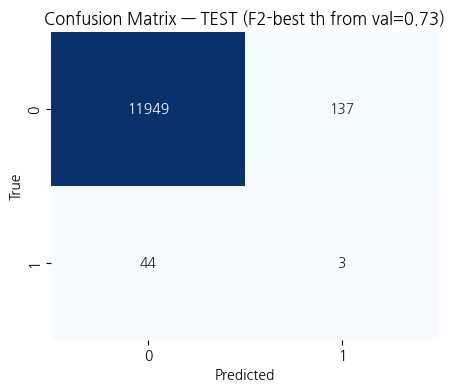

[npz] saved predictions (val+test) to /work/outputs/predictions.npz


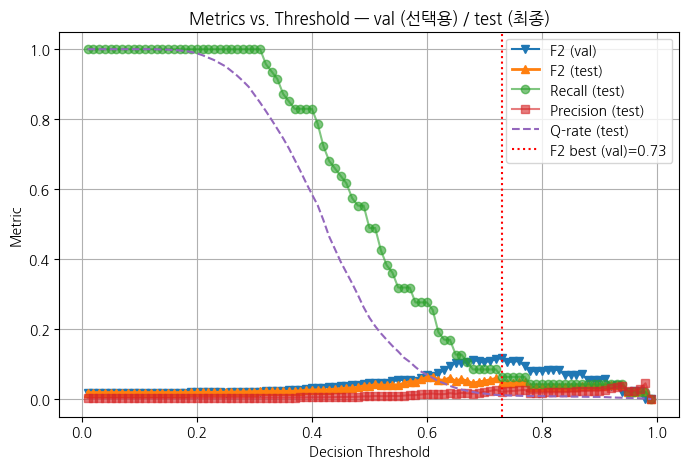

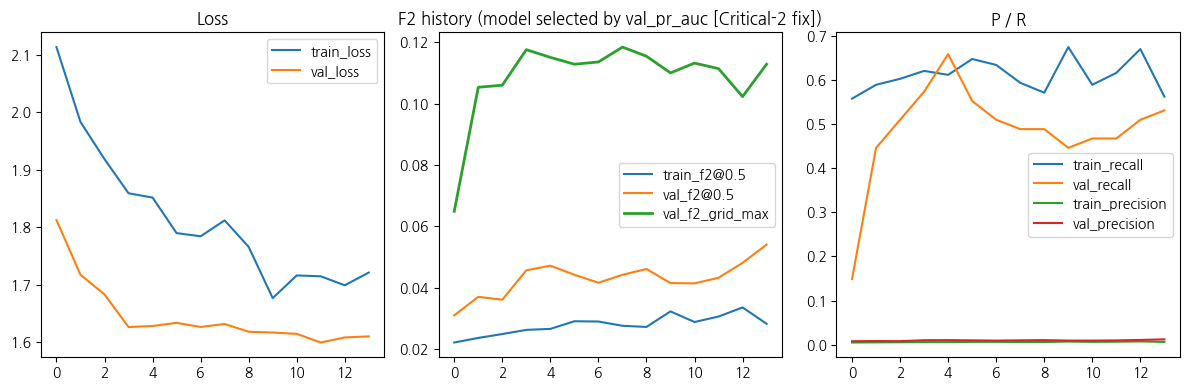


[예측 확률 기반 특성 분포 분석] 상위/하위 15%
  하위 15% (안전): 확률<= 0.3087, n=1820
  상위 15% (위험): 확률>= 0.5418, n=1820

[통계 검정 요약표]
            특성      평균차이    t-test p값    U-test p값  Cohen's d 유의성(α=0.05)
독소 생성 최적 온도 일수 -0.728022 1.599782e-27 1.525067e-13  -0.363312          유의
        저습도 일수 -1.227473 7.143317e-66 4.060683e-49  -0.579983          유의
     연속 무강수 일수  0.132418 4.375721e-02 5.949608e-02   0.066867          유의


/tmp/ipykernel_12/1929321235.py:768: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([lower_values, upper_values],
/tmp/ipykernel_12/1929321235.py:768: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([lower_values, upper_values],
/tmp/ipykernel_12/1929321235.py:768: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot([lower_values, upper_values],


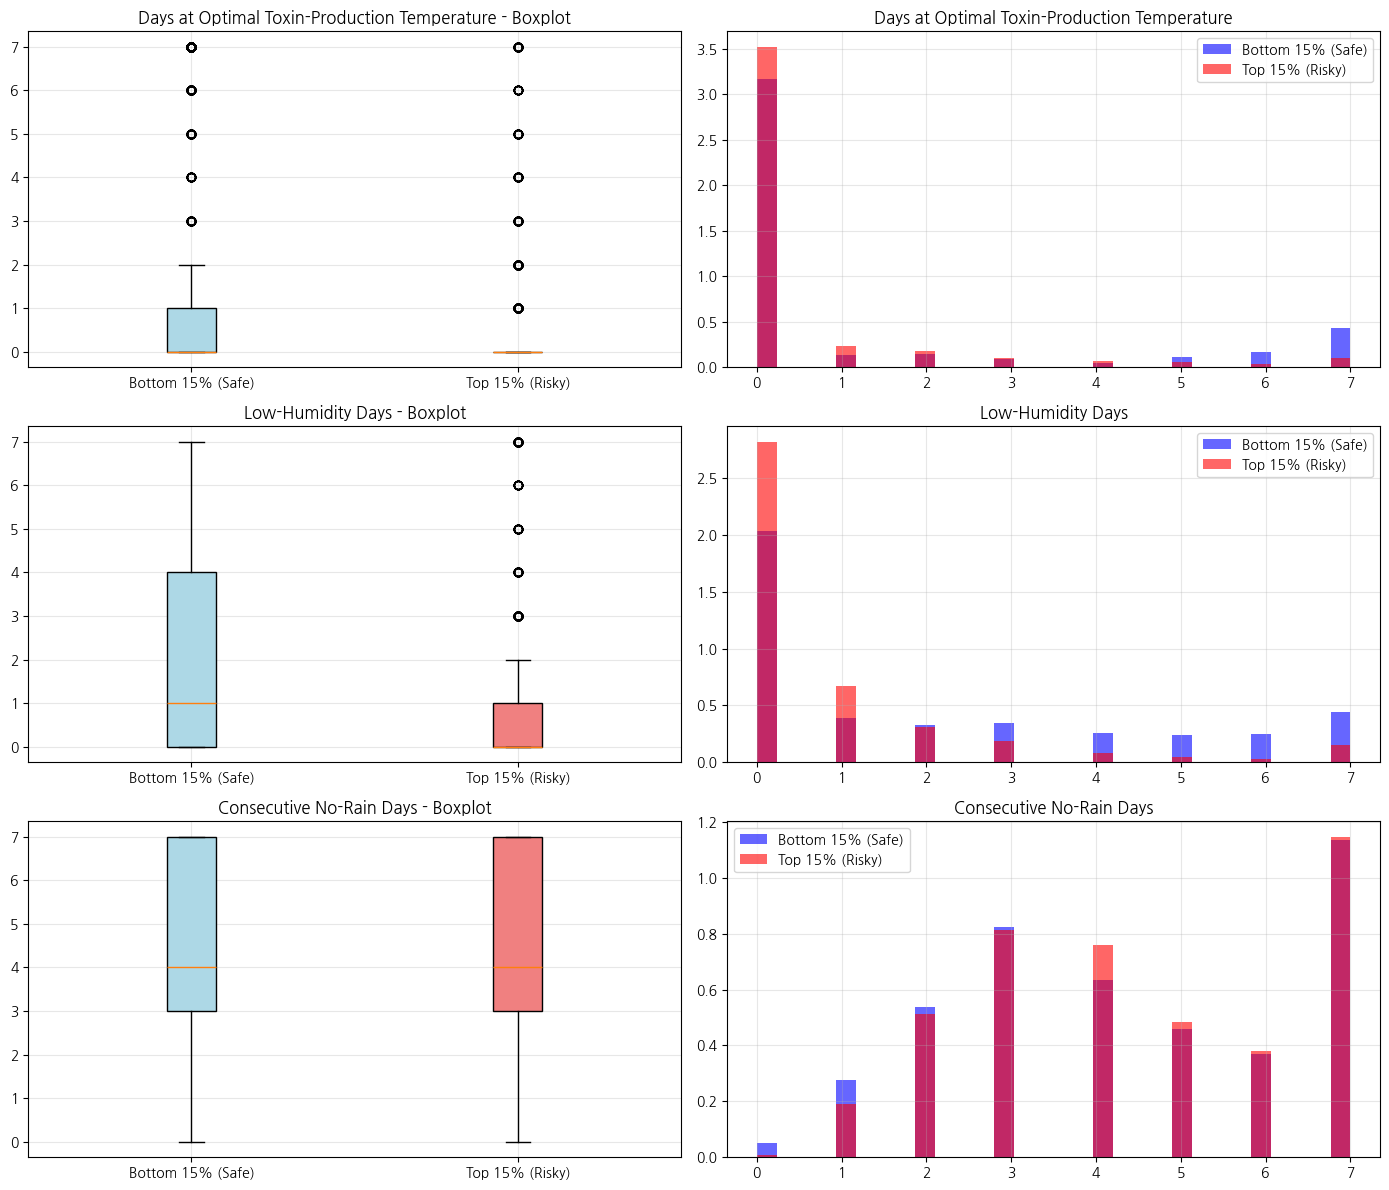

In [21]:
import numpy as np
import pandas as pd
import random
import os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, fbeta_score,
    # [DEFECT-031/D-040 fix] 불균형 0.5% 환경 표준 metric 추가
    average_precision_score, brier_score_loss,
    matthews_corrcoef, cohen_kappa_score,
)
from sklearn.dummy import DummyClassifier
import tensorflow as tf
# [DEFECT-014 fix] TF 그래프/커널 결정성 활성화 (import 이후 한 번)
tf.config.experimental.enable_op_determinism()
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.layers import Layer
import matplotlib.pyplot as plt
import seaborn as sns

# ── Display-time translation dict (data columns stay Korean) ──────────────
LABEL_KO_TO_EN = {
    "독소 생성 최적 온도 일수": "Days at Optimal Toxin-Production Temperature",
    "저습도 일수": "Low-Humidity Days",
    "연속 무강수 일수": "Consecutive No-Rain Days",
}
# ─────────────────────────────────────────────────────────────────────────────

# ==================================================
#  재현성을 위한 시드 고정 (필수)
# ==================================================
def set_seeds(seed=42):
    """모든 주요 라이브러리의 시드를 고정하여 재현성을 보장."""
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    # [DEFECT-015 fix] env vars 는 노트북 첫 셀에서 설정됨 (tensorflow import 이전)

SEED = 42
set_seeds(SEED)


# ===============================
#  Attention Layer ([DEFECT-019 fix] tf.clip_by_value 제거 — tf.nn.softmax stable form 의존)
# ===============================
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight',
                                 shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(name='att_bias',
                                 shape=(input_shape[-1],),
                                 initializer='zeros',
                                 trainable=True)
        self.u = self.add_weight(name='att_u',
                                 shape=(input_shape[-1],),
                                 initializer='glorot_uniform',
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        v = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        vu = tf.tensordot(v, self.u, axes=1)
        # [DEFECT-019 fix] tf.clip_by_value(vu, -10, 10) 제거. tf.nn.softmax 가 max-subtract
        # trick 내장으로 numerical safety 정당화 0, tanh∈[-1,1] + BN 직후 입력으로 vu 자연 bound.
        # clip 경계 hit 시 gradient=0 으로 critical attention signal 학습 차단 (4 에이전트 회의 옵션 A).
        alphas = tf.nn.softmax(vu, axis=1)
        output = tf.reduce_sum(inputs * tf.expand_dims(alphas, -1), axis=1)
        return output


# ===============================
#  Focal Loss / Weighted BCE
# ===============================
def focal_loss(alpha=0.75, gamma=2.0):
    """Focal loss (hard label 전용).

    y_true 는 binary {0, 1} 만 허용. label smoothing / soft label (e.g. 0.5) 미지원 —
    내부 `tf.where(tf.equal(y_true, 1.0), loss_pos, loss_neg)` 가 y_true∈(0,1) 을 loss_neg
    분기로 흡수해 modulating factor 비대칭 발생. 미래 label smoothing 도입 시 본 함수 재작성 필요.
    """
    # [DEFECT-016 fix] manual log(clip(p, 1e-7)) 폐기 → log_sigmoid 기반 stable form.
    # 입력은 logit z (출력 layer activation=None). 수학적 동치:
    #   log(σ(z))   = log_sigmoid(z) = -softplus(-z)
    #   log(1-σ(z)) = log_sigmoid(-z)   (1-σ(x)=σ(-x) identity)
    # p=σ(z) 는 modulating factor (1-p)^γ / p^γ 에만 사용 (log 진입 X).
    # [DEFECT-017 fix] silent NaN/Inf zero-out 두 줄 제거 — D-016 stable form 후 forward NaN
    # 발생 mathematically impossible ((1-p)→0 polynomial × softplus(-z)→e^{-z} 둘 다 0×0 decay,
    # 0×∞ indeterminate form 발생 X — architect 수학 분석). tf.where(is_nan, 0, x) backward 가
    # 0×NaN=NaN gradient 전염 (TF Issue #38349) → 기존 코드가 strictly worse than no defense
    # (forward NaN 흡수 + backward NaN 전파 + TerminateOnNaN L2250 callback 영구 dead +
    # silent model corruption). 4 에이전트 회의 만장일치 '두 줄 제거' (옵션 A 채택).
    def focal_loss_fixed(y_true, y_pred):
        y_true   = tf.cast(y_true, tf.float32)
        z        = y_pred  # logit (출력 layer activation=None)
        p        = tf.sigmoid(z)
        log_p    = tf.math.log_sigmoid(z)
        log_1mp  = tf.math.log_sigmoid(-z)
        loss_pos = alpha         * tf.pow(1.0 - p, gamma) * (-log_p)
        loss_neg = (1.0 - alpha) * tf.pow(p,       gamma) * (-log_1mp)
        loss = tf.where(tf.equal(y_true, 1.0), loss_pos, loss_neg)
        return tf.reduce_mean(loss)
    return focal_loss_fixed


def weighted_binary_crossentropy(pos_weight=None):
    # [DEFECT-039 fix] silent default 50.0 → None + assert 명시 강제.
    #   기존 default 50 의존 시 호출처 미명시 → silent 4× minority underweight (calculate_pos_weight
    #   자연값 1:neg/pos 비율 대비). 명시 강제로 silent API contract 위반 봉쇄.
    assert pos_weight is not None, (
        "weighted_binary_crossentropy: pos_weight must be explicitly provided "
        "(use calculate_pos_weight(y_train) for raw class imbalance)"
    )
    # [DEFECT-016 fix] manual log(clip(p, 1e-7)) 폐기 → tf.nn.weighted_cross_entropy_with_logits.
    # 입력은 logit z. TF 공식 stable form:
    #   (1-y)·z + (1 + (pw-1)·y) · (log(1+exp(-|z|)) + max(-z, 0))
    # 가 manual `y·pw·(-log(σ(z))) + (1-y)·(-log(1-σ(z)))` 와 mathematical equivalent 이며
    # underflow/overflow 차단. pos_weight ≈ 293 (D-008 fix 후 raw 0.5% 불균형 보존) 영역에서
    # manual log(clip) × 293 의 첫 batch loss ≈ 204 + clip boundary gradient=0 saturation 발산 차단.
    def loss(y_true, y_pred):
        y = tf.cast(y_true, tf.float32)
        return tf.reduce_mean(
            tf.nn.weighted_cross_entropy_with_logits(
                labels=y, logits=y_pred, pos_weight=pos_weight
            )
        )
    return loss


def calculate_pos_weight(y_train):
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    pos_weight = neg_count / pos_count
    print(f"\n[클래스 불균형 분석]")
    print(f"  클래스 0: {neg_count}개, 클래스 1: {pos_count}개")
    print(f"  불균형 비율: 1:{pos_weight:.1f}, pos_weight: {pos_weight:.2f}")
    return float(pos_weight)


# ==================================================
#  F2 Keras Metric (B-M3 + M-01: F1 제거, F2 단일 지표)
# ==================================================
class F2Score(tf.keras.metrics.Metric):
    """B-M3 신규: F-beta(beta=2) keras metric. recall 비중을 4배 가중."""
    def __init__(self, name='f2_score', threshold=0.5, beta=2.0, **kwargs):
        super(F2Score, self).__init__(name=name, **kwargs)
        self.beta = float(beta)
        self.precision = tf.keras.metrics.Precision(thresholds=threshold)
        self.recall = tf.keras.metrics.Recall(thresholds=threshold)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # [DEFECT-016 fix] 출력 layer 가 logit z → P/R 빌트인 (thresholds=0.5 기본) 와 mismatch.
        # 진입에 σ(z) 적용 → self.precision/recall 의 thresholds=0.5 가 sigmoid 공간에서 정상 작동.
        # 인터페이스 (__init__ threshold=0.5) sigmoid 공간 유지 → manuscript 보고값 호환.
        y_pred = tf.sigmoid(y_pred)
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        b2 = self.beta * self.beta
        eps = tf.keras.backend.epsilon()
        return (1 + b2) * (p * r) / (b2 * p + r + eps)

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()


# ==================================================
#  [DEFECT-002 fix] F2GridMonitor — 매 epoch val threshold sweep 의 max F2 를
#  logs['val_f2_grid_max'] 에 저장. EarlyStopping / ReduceLROnPlateau monitor 가
#  보고 metric (post-hoc find_optimal_threshold 의 best F2) 과 의미적으로 정합 되도록.
# ==================================================
class F2GridMonitor(tf.keras.callbacks.Callback):
    """매 epoch 끝에 val 데이터로 99-threshold (0.01~0.99, evenly spaced) grid sweep, max F2 를 logs 에 기록.

    DEFECT-002 fix: F2Score(threshold=0.5) monitor 와 보고 F2@best_th 간 임계치 불일치 제거.
    EarlyStopping(restore_best_weights=True) 의 best epoch 가 보고 metric 정의와 일치하게 됨.
    """
    def __init__(self, x_val, y_val, thresholds=None, name='val_f2_grid_max'):
        super().__init__()
        self.x_val = x_val
        self.y_val = np.asarray(y_val).astype(int).ravel()
        # [DEFECT-023 fix] np.linspace(0.01, 0.99, 99) 통일 (D-022 cap 0.01~0.99 유지, evenly spaced).
        # find_optimal_threshold.grid 와 동일 linspace 로 sync (D-002/D-022 정합성 유지).
        self.thresholds = (np.linspace(0.01, 0.99, 99)
                           if thresholds is None else np.asarray(thresholds, dtype=float))
        self.metric_name = name

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        # [DEFECT-016 fix] 출력 layer logit → grid (0.01~0.99) sweep 전에 σ 변환 필수.
        # scipy.special.expit 가 numerically stable (numpy 1/(1+exp(-z)) 의 극단 z overflow 회피).
        from scipy.special import expit as _sigmoid
        y_prob = _sigmoid(self.model.predict(self.x_val, verbose=0).ravel())
        best_f2 = 0.0
        best_th = float(self.thresholds[0])
        beta2 = 4.0  # beta=2 → beta^2=4
        for th in self.thresholds:
            y_pred = (y_prob >= th).astype(int)
            tp = int(((y_pred == 1) & (self.y_val == 1)).sum())
            fp = int(((y_pred == 1) & (self.y_val == 0)).sum())
            fn = int(((y_pred == 0) & (self.y_val == 1)).sum())
            p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            denom = beta2 * p + r
            f2 = (1 + beta2) * p * r / denom if denom > 0 else 0.0
            if f2 > best_f2:
                best_f2 = f2
                best_th = float(th)
        logs[self.metric_name] = float(best_f2)
        logs['val_f2_best_th'] = best_th
        # 학습 로그 stdout 에도 한 줄
        print(f"  [F2GridMonitor] {self.metric_name}={best_f2:.4f} @ th={best_th:.2f}")


# ==================================================
#  최적 임계치 탐색 (B-M3: F2 default)
# ==================================================
def find_optimal_threshold(y_true, y_prob, step=0.01):
    """F2 기준 최적 임계치 grid search (M-01: F1 옵션 제거)."""
    best_th, best_score = 0.5, -1.0
    # [DEFECT-023 fix] np.linspace(0.01, 0.99, 99) 통일 (D-022 cap 유지, evenly spaced).
    # step 인자는 backward-compat 유지 (호출처 영향 차단). F2GridMonitor.thresholds default 와 sync.
    grid = np.linspace(0.01, 0.99, 99)
    for th in grid:
        pred = (y_prob >= th).astype(int)
        s = fbeta_score(y_true, pred, beta=2, zero_division=0)
        if s > best_score:
            best_score, best_th = s, th
    return best_th, best_score


# ==================================================
#  Critical-1: train fold 만으로 Target_Mean fit/transform
# ==================================================
def fit_target_mean(df_train, group_col='교차_조합', target_col='JDGMNT_WORD_NAME_encoded', m=20.0):
    # [DEFECT-020 fix] m-estimate smoothing (Micci-Barreca 2001, m=20 = sklearn TargetEncoder empirical-Bayes default).
    # raw groupby.mean() 은 소표본 group cross_mean ∈ {0, 1} 극단화 → minority 라벨 누설 통로 (4 에이전트 회의 옵션 A).
    # (sum + m*prior)/(count + m) → 소표본일수록 prior 로 강하게 shrink, 대표본은 raw 와 사실상 동일.
    grouped = df_train.groupby(group_col)[target_col]
    n_g = grouped.count()
    sum_g = grouped.sum()
    prior = float(df_train[target_col].mean())
    cross_mean = (sum_g + m * prior) / (n_g + m)
    fallback = prior
    return cross_mean, fallback


def transform_target_mean(df_in, cross_mean, fallback, group_col='교차_조합'):
    return df_in[group_col].map(cross_mean).fillna(fallback).astype(float)


# ==================================================
#  [DEFECT-008 fix] SMOTE 제거 — class weighting 대체
#   - SMOTE 합성 폐기 (시계열-tabular cross-space mismatch 차단)
#   - train fold 도 raw 0.5% 불균형 유지
#   - train_and_evaluate 내부 calculate_pos_weight 가 pos_weight≈neg/pos 자동 산출
#   - DEFECT-012 (pos_weight=1.0), DEFECT-013 (dummy 50% prior) 동시 부산물 해소
# ==================================================
# ===============================
#  Data preprocessing (전면 개정: split 우선)
# ===============================
def preprocess(X_ts, X_lm, y, n_features=10, timesteps=50, random_state=42,
               val_size=0.15, test_size=0.15):
    """
    [DEFECT-001 fix] train/val/test 3-way split (70/15/15) — val 로 EarlyStopping/임계치 결정,
    test 는 단 1회 final 평가.
    [DEFECT-008 fix] SMOTE 합성 제거 — train fold 도 raw 0.5% 불균형 유지, class weighting
                     (pos_weight = neg/pos 비율, train_and_evaluate 내부 calculate_pos_weight)
                     으로 대체. 시계열-tabular cross-space mismatch 차단.
                     자동 부산물: DEFECT-012 (pos_weight=1.0) / DEFECT-013 (dummy 50% prior).
    1) reshape (시계열은 NaN check 포함)
    2) train_test_split 2단계: (1차) temp(85%) / test(15%), (2차) train(70%) / val(15%)
    3) 시계열 StandardScaler train fit -> val/test transform
    4) Target_Mean: train fold 만으로 cross_mean fit -> val/test transform
    5) tabular OneHot/num scaler fit (train) -> val/test transform
    """
    # X_ts NumPy 변환 + reshape
    if isinstance(X_ts, pd.DataFrame):
        X_ts_arr = X_ts.values
    else:
        X_ts_arr = np.asarray(X_ts)
    X_ts_arr = X_ts_arr.reshape(-1, timesteps, n_features)

    # ----- (2) split 2단계 -----
    # 1차: temp / test (test_size 분리)
    X_lm_temp_df, X_lm_test_df, X_ts_temp, X_ts_test, y_temp, y_test = train_test_split(
        X_lm, X_ts_arr, y, test_size=test_size, stratify=y, random_state=random_state
    )
    # 2차: train / val (val_size 를 temp 기준 상대비율로 환산)
    val_relative = val_size / (1.0 - test_size)
    X_lm_train_df, X_lm_val_df, X_ts_train, X_ts_val, y_train, y_val = train_test_split(
        X_lm_temp_df, X_ts_temp, y_temp,
        test_size=val_relative, stratify=y_temp, random_state=random_state
    )
    print(f"[DEFECT-001 fix / split] train={len(y_train)} ({len(y_train)/len(y):.1%}), "
          f"val={len(y_val)} ({len(y_val)/len(y):.1%}), "
          f"test={len(y_test)} ({len(y_test)/len(y):.1%})")
    print(f"  train pos={int(y_train.sum())}, val pos={int(y_val.sum())}, test pos={int(y_test.sum())}")

    # ----- (3) 시계열 scaler: train fit -> val/test transform  (A-M1) -----
    ts_scaler = StandardScaler()
    X_ts_train_2d = X_ts_train.reshape(-1, n_features)
    X_ts_train_2d = ts_scaler.fit_transform(X_ts_train_2d)
    X_ts_val_2d = ts_scaler.transform(X_ts_val.reshape(-1, n_features))
    X_ts_test_2d = ts_scaler.transform(X_ts_test.reshape(-1, n_features))
    X_ts_train = X_ts_train_2d.reshape(-1, timesteps, n_features)
    X_ts_val = X_ts_val_2d.reshape(-1, timesteps, n_features)
    X_ts_test = X_ts_test_2d.reshape(-1, timesteps, n_features)
    print(f"[A-M1 / 시계열 scaler] fit on train only. "
          f"mean[:3]={ts_scaler.mean_[:3].round(4)}, scale[:3]={ts_scaler.scale_[:3].round(4)}")

    # [DEFECT-018 fix] silent NaN/Inf zero-fill -> assert fail-fast 교체. NB1 cell 44
    # fix_nan_auto_group (bfill/ffill + fillna(0)) 통과 후 NaN 부재 invariant 검증.
    # scaler fit_transform 의 zero-variance corner case 시 silent zero-fill 대신 explicit
    # AssertionError 로 노출. NB1 fillna(0) 자체의 missing-pattern 마스킹은 D-025 신규 결함 분리.
    assert not (np.isnan(X_ts_train).any() or np.isinf(X_ts_train).any()), \
        '[DEFECT-018] X_ts_train NaN/Inf detected post-scaler -- investigate zero-variance column or NB1 cascade'
    assert not (np.isnan(X_ts_val).any() or np.isinf(X_ts_val).any()), \
        '[DEFECT-018] X_ts_val NaN/Inf detected post-scaler -- investigate zero-variance column or NB1 cascade'
    assert not (np.isnan(X_ts_test).any() or np.isinf(X_ts_test).any()), \
        '[DEFECT-018] X_ts_test NaN/Inf detected post-scaler -- investigate zero-variance column or NB1 cascade'

    # ----- (4) Target_Mean: train fold 만으로 fit  (Critical-1) -----
    df_train_for_tm = X_lm_train_df.copy()
    df_train_for_tm['JDGMNT_WORD_NAME_encoded'] = y_train.values if hasattr(y_train, 'values') else y_train
    cross_mean, fallback = fit_target_mean(df_train_for_tm,
                                           group_col='교차_조합',
                                           target_col='JDGMNT_WORD_NAME_encoded')
    X_lm_train_df = X_lm_train_df.copy()
    X_lm_val_df = X_lm_val_df.copy()
    X_lm_test_df = X_lm_test_df.copy()
    X_lm_train_df['Target_Mean'] = transform_target_mean(X_lm_train_df, cross_mean, fallback)
    X_lm_val_df['Target_Mean']   = transform_target_mean(X_lm_val_df,   cross_mean, fallback)
    X_lm_test_df['Target_Mean']  = transform_target_mean(X_lm_test_df,  cross_mean, fallback)
    print(f"[Critical-1 / Target_Mean] fit on train only. "
          f"unique 조합={cross_mean.shape[0]}, fallback={fallback:.4f}")
    print(f"  train Target_Mean stat: min={X_lm_train_df['Target_Mean'].min():.4f}, "
          f"max={X_lm_train_df['Target_Mean'].max():.4f}, "
          f"mean={X_lm_train_df['Target_Mean'].mean():.4f}")

    # 키 컬럼 제거 (모델 입력에서 제외)
    for _df in (X_lm_train_df, X_lm_val_df, X_lm_test_df):
        if '교차_조합' in _df.columns:
            _df.drop(columns=['교차_조합'], inplace=True)

    # ----- (5) one-hot + num scaler: train fit -> val/test transform  (A-M1) -----
    cat_cols = ['INSPCT_PURPS_NAME', '1차 식품 분류']
    num_cols = ['Target_Mean', '독소 생성 최적 온도 일수', '저습도 일수', '연속 무강수 일수']

    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_cat_train = encoder.fit_transform(X_lm_train_df[cat_cols])
    X_cat_val   = encoder.transform(X_lm_val_df[cat_cols])
    X_cat_test  = encoder.transform(X_lm_test_df[cat_cols])

    num_scaler = StandardScaler()
    X_num_train = num_scaler.fit_transform(X_lm_train_df[num_cols])
    X_num_val   = num_scaler.transform(X_lm_val_df[num_cols])
    X_num_test  = num_scaler.transform(X_lm_test_df[num_cols])
    print(f"[A-M1 / tabular num scaler] fit on train only. "
          f"mean={num_scaler.mean_.round(4)}, scale={num_scaler.scale_.round(4)}")

    # [DEFECT-018 fix] silent NaN/Inf zero-fill -> assert fail-fast 교체. NB1 fillna(0)
    # + num_scaler.fit_transform 후 NaN 부재 invariant. zero-variance corner case 시 fail-fast.
    # NB1 fillna(0) silent zero-fill 자체는 D-025 신규 결함 분리 보고.
    assert not (np.isnan(X_num_train).any() or np.isinf(X_num_train).any()), \
        '[DEFECT-018] X_num_train NaN/Inf detected post-scaler -- investigate zero-variance column or NB1 cascade'
    assert not (np.isnan(X_num_val).any() or np.isinf(X_num_val).any()), \
        '[DEFECT-018] X_num_val NaN/Inf detected post-scaler -- investigate zero-variance column or NB1 cascade'
    assert not (np.isnan(X_num_test).any() or np.isinf(X_num_test).any()), \
        '[DEFECT-018] X_num_test NaN/Inf detected post-scaler -- investigate zero-variance column or NB1 cascade'

    X_lm_train_arr = np.hstack([X_cat_train, X_num_train]).astype(np.float32)
    X_lm_val_arr   = np.hstack([X_cat_val,   X_num_val  ]).astype(np.float32)
    X_lm_test_arr  = np.hstack([X_cat_test,  X_num_test ]).astype(np.float32)
    n_cat = X_cat_train.shape[1]
    cat_feature_idx = list(range(n_cat))  # 앞쪽이 모두 one-hot

    # ----- [DEFECT-008 fix] SMOTE 제거 — train fold 도 raw 0.5% 불균형 유지 -----
    #   class weighting (pos_weight) 으로 minority 처리: train_and_evaluate 내부에서
    #   calculate_pos_weight(y_train) 이 자동 산출 → DEFECT-012 동시 해소.
    #   DummyClassifier 도 raw train 으로 fit → DEFECT-013 동시 해소.
    X_ts_train = X_ts_train.astype(np.float32)
    y_train_arr = np.asarray(y_train)

    # 후속 NaN/Inf 검사 — [DEFECT-008 fix] SMOTE 제거 후 raw train 통계
    print(f"\n[최종 체크 — DEFECT-008 fix: SMOTE 제거]")
    print(f"  X_ts_train shape={X_ts_train.shape}, "
          f"NaN={int(np.isnan(X_ts_train).sum())}, Inf={int(np.isinf(X_ts_train).sum())}")
    print(f"  X_lm_train_arr shape={X_lm_train_arr.shape}, "
          f"NaN={int(np.isnan(X_lm_train_arr).sum())}, Inf={int(np.isinf(X_lm_train_arr).sum())}")
    pos_ratio = float(y_train_arr.mean())
    print(f"  y_train 클래스 1 비율 (raw, no SMOTE): {pos_ratio:.4f}")
    print(f"  X_ts_val shape={X_ts_val.shape}, X_lm_val_arr shape={X_lm_val_arr.shape}, "
          f"y_val 클래스 1 비율={float(np.asarray(y_val).mean()):.4f}")
    print(f"  X_ts_test shape={X_ts_test.shape}, X_lm_test_arr shape={X_lm_test_arr.shape}, "
          f"y_test 클래스 1 비율={float(np.asarray(y_test).mean()):.4f}")

    return (X_ts_train, X_lm_train_arr, y_train_arr,
            X_ts_val,  X_lm_val_arr,  np.asarray(y_val),
            X_ts_test, X_lm_test_arr, np.asarray(y_test))


# ===============================
#  Hybrid Model (F2 metric 추가)
# ===============================
# ===============================
#  Hybrid Model (F2 metric 추가)
# ===============================
def build_hybrid_model(n_timestamps, n_features_ts, n_tab_features,
                       lstm_units=64, fnn_units=[64, 32],
                       dropout=0.3, learning_rate=1e-4,
                       loss_type='weighted_bce', pos_weight=None):
    ts_input = layers.Input(shape=(n_timestamps, n_features_ts), name='ts_input')
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True,
                                         kernel_regularizer=tf.keras.regularizers.l2(0.001)))(ts_input)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Bidirectional(layers.LSTM(lstm_units // 2, return_sequences=True,
                                         kernel_regularizer=tf.keras.regularizers.l2(0.001)))(x)
    x = layers.BatchNormalization()(x)
    att_out = AttentionLayer()(x)
    att_out = layers.Dropout(dropout)(att_out)

    tab_input = layers.Input(shape=(n_tab_features,), name='tab_input')
    t = layers.Dense(fnn_units[0], activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001))(tab_input)
    t = layers.BatchNormalization()(t)
    t = layers.Dropout(dropout)(t)
    t = layers.Dense(fnn_units[1], activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001))(t)
    t = layers.BatchNormalization()(t)
    t = layers.Dropout(dropout)(t)

    merged = layers.Concatenate()([att_out, t])
    m = layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001))(merged)
    m = layers.BatchNormalization()(m)
    m = layers.Dropout(dropout)(m)
    # [DEFECT-016 fix] activation=None → logit z 출력 (BCE-with-logits stable form 입력).
    # inference 시 scipy.special.expit / tf.sigmoid 로 확률 복원. metric/loss 모두 logit 호환 처리.
    output = layers.Dense(1, activation=None)(m)

    model = models.Model(inputs=[ts_input, tab_input], outputs=output)
    opt = optimizers.Adam(learning_rate, clipnorm=1.0)

    if loss_type == 'weighted_bce':
        # [DEFECT-039 fix] silent default 50.0 fallback 제거 → 명시 강제 (assert).
        #   build_model_v2_split_input 외부 직접 호출 시 pos_weight 미명시 차단.
        #   train_and_evaluate L495 calculate_pos_weight(y_train) 산출 → L500 명시 전달 path 무영향.
        assert pos_weight is not None, (
            "build_model_v2_split_input(loss_type='weighted_bce'): "
            "pos_weight must be explicitly provided "
            "(use calculate_pos_weight(y_train) for raw class imbalance)"
        )
        loss_fn = weighted_binary_crossentropy(pos_weight=pos_weight)
        print(f"\n[손실] Weighted BCE (pos_weight={pos_weight:.2f})")
    elif loss_type == 'focal':
        loss_fn = focal_loss(alpha=0.75, gamma=2)
        print("\n[손실] Focal Loss (alpha=0.75, gamma=2)")
    else:
        # [DEFECT-016 fix] 'binary_crossentropy' string 은 from_logits=False 기본 →
        # 출력 layer linear (logit) 와 mismatch. BinaryCrossentropy(from_logits=True) 명시.
        loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)
        print("\n[손실] Binary CE with logits (fit()에서 class_weight 사용)")

    # B-M3: F2Score metric 추가
    model.compile(optimizer=opt,
                  loss=loss_fn,
                  # [DEFECT-034 fix] 'accuracy' 제거 — 0.5% 불균형에서 trivially 99.5% (전체
                  # negative 예측), 학습 monitor 의미 0.
                  # [DEFECT-031 fix] PR-AUC AUC 추가 — ROC-AUC 단독 보고는 불균형 환경에서
                  # over-optimistic (Saito & Rehmsmeier 2015).
                  metrics=[
                           # [DEFECT-016 fix] logit 입력 → thresholds=0.0 (sigmoid 가 monotonic →
                           # z>=0 ⟺ σ(z)>=0.5 → confusion matrix sigmoid 공간 0.5 와 수치적 동일).
                           tf.keras.metrics.Recall(name='recall', thresholds=0.0),
                           tf.keras.metrics.Precision(name='precision', thresholds=0.0),
                           F2Score(name='f2_score'),
                           # [DEFECT-016 fix] tf.keras.metrics.AUC 가 내부 200 thresholds 를 [0,1]
                           # 균등 분포로 두기 때문에 logit 공간 (-inf, +inf) 에서 saturation. from_logits=True
                           # 명시 시 내부 sigmoid 적용 → 정확한 AUC 산출.
                           tf.keras.metrics.AUC(name='auc', from_logits=True),
                           # [DEFECT-031 fix] PR-AUC (curve='PR') — 불균형 환경 표준 monitor.
                           tf.keras.metrics.AUC(name='pr_auc', curve='PR', from_logits=True)])
    return model


# ===============================
#  Training & Evaluation (F2 monitor + Dummy baseline + fbeta_score)
# ===============================
def train_and_evaluate(X_ts_train, X_tab_train, y_train,
                       X_ts_val, X_tab_val, y_val,
                       X_ts_test, X_tab_test, y_test,
                       epochs=50, batch_size=256,
                       loss_type='weighted_bce'):
    """
    [DEFECT-001 fix] val 로 EarlyStopping + ReduceLROnPlateau + threshold tuning,
    test 는 단 1회 final 평가 (보고용).
    """
    print("\n[학습 전 데이터 검증]")
    print(f"  X_ts_train: NaN={int(np.isnan(X_ts_train).sum())}, Inf={int(np.isinf(X_ts_train).sum())}")
    print(f"  X_tab_train: NaN={int(np.isnan(X_tab_train).sum())}, Inf={int(np.isinf(X_tab_train).sum())}")

    pos_weight = calculate_pos_weight(y_train)

    model = build_hybrid_model(n_timestamps=X_ts_train.shape[1],
                               n_features_ts=X_ts_train.shape[2],
                               n_tab_features=X_tab_train.shape[1],
                               loss_type=loss_type,
                               pos_weight=pos_weight)

    # [Critical-2 fix] F2GridMonitor 의 val 99-threshold sweep best F2 를 monitor 로 쓰면
    # 매 epoch 마다 val 의 optimal threshold 정보가 weight 선택에 누설 (subtle val leakage).
    # → EarlyStopping/ReduceLROnPlateau 의 monitor 만 임계치 비의존 'val_pr_auc'(불균형 적합)
    # 로 변경. F2GridMonitor 는 history 기록·진단용으로만 유지 (model selection 신호에서 분리).
    f2_grid = F2GridMonitor(
        x_val={'ts_input': X_ts_val, 'tab_input': X_tab_val},
        y_val=y_val,
    )
    es = callbacks.EarlyStopping(monitor='val_pr_auc', patience=10, mode='max',
                                 restore_best_weights=True, verbose=1)
    rl = callbacks.ReduceLROnPlateau(monitor='val_pr_auc', factor=0.5, patience=5,
                                     mode='max', min_lr=1e-7, verbose=1)
    nan_terminate = callbacks.TerminateOnNaN()

    class_weight_dict = None
    if loss_type == 'class_weight':
        neg_count = (y_train == 0).sum()
        pos_count = (y_train == 1).sum()
        class_weight_dict = {0: 1.0, 1: neg_count / pos_count}

    history = model.fit(
        {'ts_input': X_ts_train, 'tab_input': X_tab_train}, y_train,
        validation_data=({'ts_input': X_ts_val, 'tab_input': X_tab_val}, y_val),
        epochs=epochs, batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=[f2_grid, es, rl, nan_terminate],  # f2_grid 가 logs 먼저 채움
        verbose=1
    )

    # 예측: val 로 threshold 결정, test 로 final 보고
    # [DEFECT-016 fix] 출력 layer logit → scipy.special.expit 로 확률 변환 (numerically stable).
    # downstream: find_optimal_threshold (0.01~0.99 grid), classification_report, calibration_curve,
    # analyze_prediction_distribution, DummyClassifier 비교 모두 sigmoid 공간 유지.
    from scipy.special import expit as _sigmoid
    y_prob_val  = _sigmoid(model.predict({'ts_input': X_ts_val,  'tab_input': X_tab_val }).ravel())
    y_prob_test = _sigmoid(model.predict({'ts_input': X_ts_test, 'tab_input': X_tab_test}).ravel())

    # B-M3: val 기준 F2 최적 임계치 결정 (test 라벨 미사용)
    best_th_f2, best_score_f2_val = find_optimal_threshold(np.asarray(y_val), y_prob_val)
    # [DEFECT-024 fix] best_th_f2/best_score_f2_val (numpy float64) → float32 캐스팅.
    # y_prob (TF model.predict + scipy.expit) 가 float32 이므로 비교/저장/plot 모두 일관 float32 boundary.
    best_th_f2 = np.float32(best_th_f2)
    best_score_f2_val = np.float32(best_score_f2_val)
    y_pred_val  = (y_prob_val  >= best_th_f2).astype(int)
    y_pred_test = (y_prob_test >= best_th_f2).astype(int)

    print(f"\n[B-M3 / val] F2 최적 임계치={best_th_f2:.3f}, F2(val)={best_score_f2_val:.4f}")
    print("\n[Classification Report — val (임계치 선택용)]")
    print(classification_report(y_val, y_pred_val, digits=4))

    print("\n" + "="*70)
    print("[Final Test 평가 — 단 1회, val 에서 결정된 임계치 적용]")
    print("="*70)
    print(classification_report(y_test, y_pred_test, digits=4))
    # [DEFECT-031/D-040 fix] 불균형 0.5% 환경 표준 metric 4 개 추가 산출.
    #   - PR-AUC (average_precision_score)  : ROC-AUC over-optimistic 보완
    #   - Brier score (brier_score_loss)    : 확률 calibration 정확도
    #   - MCC (matthews_corrcoef)           : 불균형 binary 표준 metric
    #   - Cohen's kappa (cohen_kappa_score) : chance 보정 agreement
    test_roc_auc = roc_auc_score(y_test, y_prob_test)
    test_pr_auc  = average_precision_score(y_test, y_prob_test)
    test_brier   = brier_score_loss(y_test, y_prob_test)
    test_mcc     = matthews_corrcoef(y_test, y_pred_test)
    test_kappa   = cohen_kappa_score(y_test, y_pred_test)
    test_f2      = fbeta_score(y_test, y_pred_test, beta=2, zero_division=0)
    print(f"Test ROC-AUC    : {test_roc_auc:.4f}")
    print(f"Test PR-AUC     : {test_pr_auc:.4f}")
    print(f"Test Brier      : {test_brier:.4f}")
    print(f"Test MCC        : {test_mcc:.4f}")
    print(f"Test Cohen kappa: {test_kappa:.4f}")
    print(f"Test F2         : {test_f2:.4f}")

    # === B-M5: DummyClassifier baseline 비교 (test 에서 평가) ===
    # NOTE: dummy.fit 데이터는 train (raw, no SMOTE) — [DEFECT-013 자동 해소]
    #       DEFECT-008 fix (SMOTE 제거) 의 인과적 부산물.
    dummy_results = []
    for strategy in ['most_frequent', 'stratified']:
        dc = DummyClassifier(strategy=strategy, random_state=42)
        dc.fit(X_tab_train, y_train)
        dy_test = dc.predict(X_tab_test)
        dummy_results.append({
            'model': f'Dummy({strategy})',
            'precision': precision_score(y_test, dy_test, zero_division=0),
            'recall':    recall_score(y_test, dy_test, zero_division=0),
            'f2':        fbeta_score(y_test, dy_test, beta=2, zero_division=0),
        })
    dummy_results.append({
        'model': 'Hybrid (F2 best th from val)',
        'precision': precision_score(y_test, y_pred_test, zero_division=0),
        'recall':    recall_score(y_test, y_pred_test, zero_division=0),
        'f2':        fbeta_score(y_test, y_pred_test, beta=2, zero_division=0),
    })
    baseline_df = pd.DataFrame(dummy_results)
    print("\n[B-M5] DummyClassifier baseline 비교 (test set)")
    print(baseline_df.to_string(index=False))

    # Confusion Matrix (test)
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix — TEST (F2-best th from val={best_th_f2:.2f})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Threshold 분석 (val 곡선 + test 최종 점)
    # [DEFECT-023 fix] 검색 grid (find_optimal_threshold) 와 axis 일치 (linspace 99점 통일).
    thresholds = np.linspace(0.01, 0.99, 99)
    recalls_val,  precisions_val,  f2s_val,  q_rates_val  = [], [], [], []
    recalls_test, precisions_test, f2s_test, q_rates_test = [], [], [], []
    for th in thresholds:
        pred_v = (y_prob_val  >= th).astype(int)
        pred_t = (y_prob_test >= th).astype(int)
        recalls_val.append(recall_score(y_val, pred_v, zero_division=0))
        precisions_val.append(precision_score(y_val, pred_v, zero_division=0))
        f2s_val.append(fbeta_score(y_val, pred_v, beta=2, zero_division=0))
        q_rates_val.append(np.mean(pred_v))
        recalls_test.append(recall_score(y_test, pred_t, zero_division=0))
        precisions_test.append(precision_score(y_test, pred_t, zero_division=0))
        f2s_test.append(fbeta_score(y_test, pred_t, beta=2, zero_division=0))
        q_rates_test.append(np.mean(pred_t))

    # Save predictions for later figure re-rendering (GPU not required)
    import os as _os, numpy as _np
    _save_dir = '/work/outputs' if _os.path.isdir('/work/outputs') else '.'
    _np.savez(
        _os.path.join(_save_dir, 'predictions.npz'),
        y_val=_np.asarray(y_val), y_prob_val=_np.asarray(y_prob_val),
        y_test=_np.asarray(y_test), y_prob_test=_np.asarray(y_prob_test),
        best_th_f2=best_th_f2, best_score_f2_val=best_score_f2_val,
        # [DEFECT-024 fix] thresholds (np.linspace float64) → float32 저장 일관 dtype.
        thresholds=_np.asarray(thresholds, dtype=_np.float32),
        recalls_val=_np.asarray(recalls_val), precisions_val=_np.asarray(precisions_val),
        f2s_val=_np.asarray(f2s_val), q_rates_val=_np.asarray(q_rates_val),
        recalls_test=_np.asarray(recalls_test), precisions_test=_np.asarray(precisions_test),
        f2s_test=_np.asarray(f2s_test), q_rates_test=_np.asarray(q_rates_test),
    )
    print(f"[npz] saved predictions (val+test) to {_save_dir}/predictions.npz")

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f2s_val,  label='F2 (val)',  marker='v')
    plt.plot(thresholds, f2s_test, label='F2 (test)', marker='^', linewidth=2)
    plt.plot(thresholds, recalls_test,    label='Recall (test)',    marker='o', alpha=0.6)
    plt.plot(thresholds, precisions_test, label='Precision (test)', marker='s', alpha=0.6)
    plt.plot(thresholds, q_rates_test,    label='Q-rate (test)',    linestyle='--')
    plt.axvline(best_th_f2, color='red', linestyle=':', label=f'F2 best (val)={best_th_f2:.2f}')
    plt.xlabel('Decision Threshold')
    plt.ylabel('Metric')
    plt.title('Metrics vs. Threshold — val (선택용) / test (최종)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 학습 곡선 (F2 단일 지표)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    if 'f2_score' in history.history:
        plt.plot(history.history['f2_score'], label='train_f2@0.5')
        plt.plot(history.history['val_f2_score'], label='val_f2@0.5')
    if 'val_f2_grid_max' in history.history:
        plt.plot(history.history['val_f2_grid_max'], label='val_f2_grid_max', linewidth=2)
    plt.title('F2 history (model selected by val_pr_auc [Critical-2 fix])')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history['recall'], label='train_recall')
    plt.plot(history.history['val_recall'], label='val_recall')
    plt.plot(history.history['precision'], label='train_precision')
    plt.plot(history.history['val_precision'], label='val_precision')
    plt.title('P / R')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return model, y_prob_test, baseline_df, best_th_f2


# ===============================
#  예측 확률 기반 특성 분석 함수 (변경 없음, 기존 유지)
# ===============================
# ===============================
#  예측 확률 기반 특성 분석 함수 (변경 없음, 기존 유지)
# ===============================
def analyze_prediction_distribution(y_prob, X_lm_original, percentile=15):
    from scipy import stats
    feature_cols = ['독소 생성 최적 온도 일수', '저습도 일수', '연속 무강수 일수']
    lower_threshold = np.percentile(y_prob, percentile)
    upper_threshold = np.percentile(y_prob, 100 - percentile)
    lower_idx = y_prob <= lower_threshold
    upper_idx = y_prob >= upper_threshold

    print("\n" + "="*70)
    print(f"[예측 확률 기반 특성 분포 분석] 상위/하위 {percentile}%")
    print("="*70)
    print(f"  하위 {percentile}% (안전): 확률<= {lower_threshold:.4f}, n={lower_idx.sum()}")
    print(f"  상위 {percentile}% (위험): 확률>= {upper_threshold:.4f}, n={upper_idx.sum()}")

    results = {}
    for feature in feature_cols:
        lower_values = X_lm_original[lower_idx][feature]
        upper_values = X_lm_original[upper_idx][feature]

        mean_lower = lower_values.mean(); mean_upper = upper_values.mean()
        median_lower = lower_values.median(); median_upper = upper_values.median()
        std_lower = lower_values.std(); std_upper = upper_values.std()

        t_stat, t_pval = stats.ttest_ind(lower_values, upper_values)
        u_stat, u_pval = stats.mannwhitneyu(lower_values, upper_values, alternative='two-sided')
        levene_stat, levene_pval = stats.levene(lower_values, upper_values)
        pooled_std = np.sqrt(((len(lower_values)-1)*std_lower**2 + (len(upper_values)-1)*std_upper**2) /
                             (len(lower_values) + len(upper_values) - 2))
        cohens_d = (mean_upper - mean_lower) / pooled_std if pooled_std else 0.0

        results[feature] = {
            'mean_lower': mean_lower, 'mean_upper': mean_upper,
            'median_lower': median_lower, 'median_upper': median_upper,
            'std_lower': std_lower, 'std_upper': std_upper,
            't_statistic': t_stat, 't_pvalue': t_pval,
            'u_statistic': u_stat, 'u_pvalue': u_pval,
            'levene_pvalue': levene_pval, 'cohens_d': cohens_d
        }

    summary_df = pd.DataFrame({
        '특성': feature_cols,
        '평균차이': [results[f]['mean_upper'] - results[f]['mean_lower'] for f in feature_cols],
        't-test p값': [results[f]['t_pvalue'] for f in feature_cols],
        'U-test p값': [results[f]['u_pvalue'] for f in feature_cols],
        "Cohen's d": [results[f]['cohens_d'] for f in feature_cols],
        '유의성(α=0.05)': ['유의' if results[f]['t_pvalue'] < 0.05 else '비유의' for f in feature_cols]
    })
    print("\n[통계 검정 요약표]")
    print(summary_df.to_string(index=False))

    # 시각화
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    for idx, feature in enumerate(feature_cols):
        lower_values = X_lm_original.loc[lower_idx, feature]
        upper_values = X_lm_original.loc[upper_idx, feature]
        ax1 = axes[idx, 0]
        bp = ax1.boxplot([lower_values, upper_values],
                         labels=[f'Bottom {percentile}% (Safe)', f'Top {percentile}% (Risky)'],
                         patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax1.set_title(f"{LABEL_KO_TO_EN.get(feature, feature)} - Boxplot")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[idx, 1]
        ax2.hist(lower_values, bins=30, alpha=0.6, label=f'Bottom {percentile}% (Safe)',
                 color='blue', density=True)
        ax2.hist(upper_values, bins=30, alpha=0.6, label=f'Top {percentile}% (Risky)',
                 color='red', density=True)
        ax2.set_title(LABEL_KO_TO_EN.get(feature, feature))
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return results, summary_df


# ===============================
#  Main Execution
# ===============================
if __name__ == "__main__":
    # n_features=10 (시계열 prefix 10개)
    # [DEFECT-001 fix] 9-tuple unpack: train/val/test 3-way (70/15/15)
    (X_ts_train, X_tab_train, y_train,
     X_ts_val,  X_tab_val,  y_val,
     X_ts_test, X_tab_test, y_test) = preprocess(
        X_ts, X_lm, y, n_features=10, timesteps=50, random_state=42,
        val_size=0.15, test_size=0.15,
    )

    print(f"\nTraining shapes (DEFECT-008 fix — SMOTE 제거, raw 0.5% 불균형 유지):")
    print(f"  X_ts_train: {X_ts_train.shape}")
    print(f"  X_tab_train: {X_tab_train.shape}")
    print(f"  y_train: {y_train.shape}, 클래스 1 비율: {np.asarray(y_train).mean():.4f}")
    print(f"\nValidation shapes (No SMOTE — 원본 0.5% 불균형 유지):")
    print(f"  X_ts_val: {X_ts_val.shape}, X_tab_val: {X_tab_val.shape}")
    print(f"  y_val: {y_val.shape}, 클래스 1 비율: {np.asarray(y_val).mean():.4f}")
    print(f"\nTest shapes (No SMOTE — final 평가, 단 1회):")
    print(f"  X_ts_test: {X_ts_test.shape}, X_tab_test: {X_tab_test.shape}")
    print(f"  y_test: {y_test.shape}, 클래스 1 비율: {np.asarray(y_test).mean():.4f}")

    print("\n" + "="*50)
    print("Hybrid LSTM+FNN 학습 (Weighted BCE + F2 monitor)")
    print("="*50)
    model, y_prob_test, baseline_df, best_th_f2 = train_and_evaluate(
        X_ts_train, X_tab_train, y_train,
        X_ts_val,  X_tab_val,  y_val,
        X_ts_test, X_tab_test, y_test,
        epochs=50, batch_size=256,
        loss_type='weighted_bce'
    )

    # [DEFECT-001 fix] 검증 데이터 원본 (Target_Mean 인코딩 전 raw) — test 와 동일 인덱스로 재현
    from sklearn.model_selection import train_test_split
    _X_lm_temp, X_lm_test_original, _y_temp, _y_test_orig = train_test_split(
        X_lm, y, test_size=0.15, stratify=y, random_state=42
    )
    results, summary_df = analyze_prediction_distribution(
        y_prob=y_prob_test,
        X_lm_original=X_lm_test_original,
        percentile=15
    )

### [영역 M / 시각화 한글 폰트 + F2]
- 모든 시각화 라벨/타이틀을 한글로 통일하고 Malgun Gothic 폰트를 적용한다.
- 임계치-지표 그래프에 F2(재현율 가중) 라인을 추가하여 식약처 운영 시나리오와 일치시킨다.


[font_helper] 한글 폰트 적용: NanumGothic (axes.unicode_minus=False)

[모델 성능 시각화] ROC, PR, Threshold, Calibration, Distribution, Lift
  1/380 [..............................] - ETA: 15s

 10/380 [..............................] - ETA: 2s 

 19/380 [>.............................] - ETA: 2s

 28/380 [=>............................] - ETA: 1s

 38/380 [==>...........................] - ETA: 1s

...

348/380 [==========================>...] - ETA: 0s

359/380 [===========================>..] - ETA: 0s

370/380 [============================>.] - ETA: 0s

380/380 [==============================] - ETA: 0s

380/380 [==============================] - 2s 5ms/step


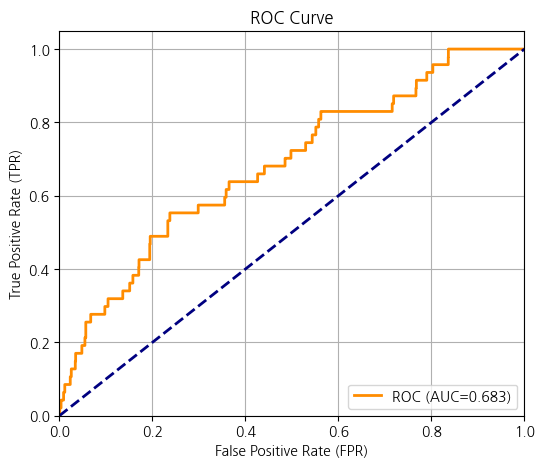

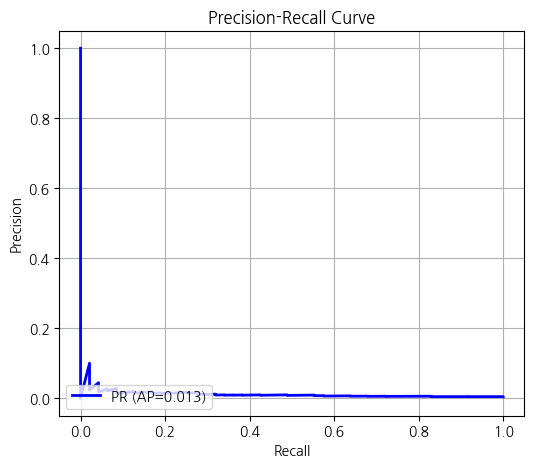

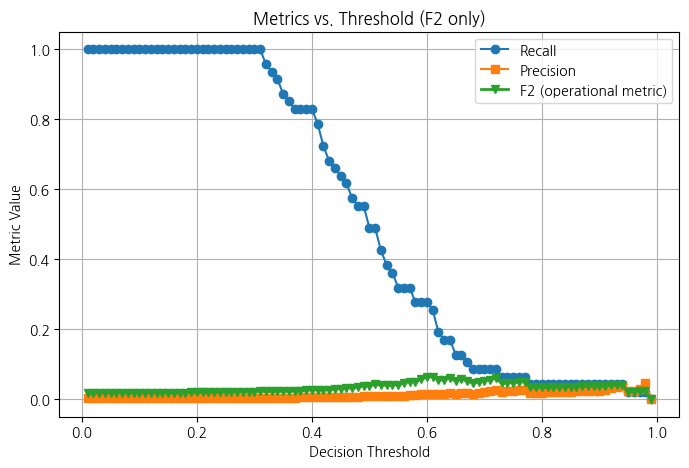

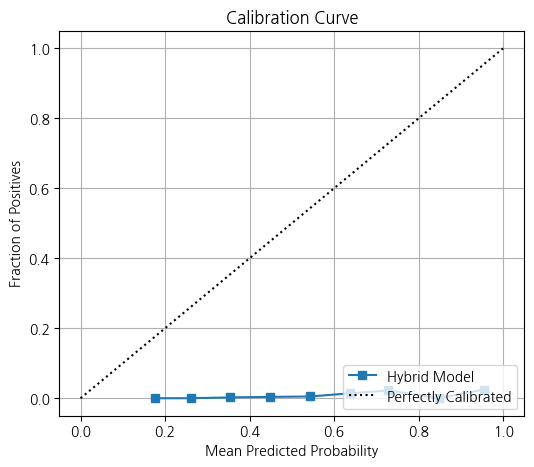

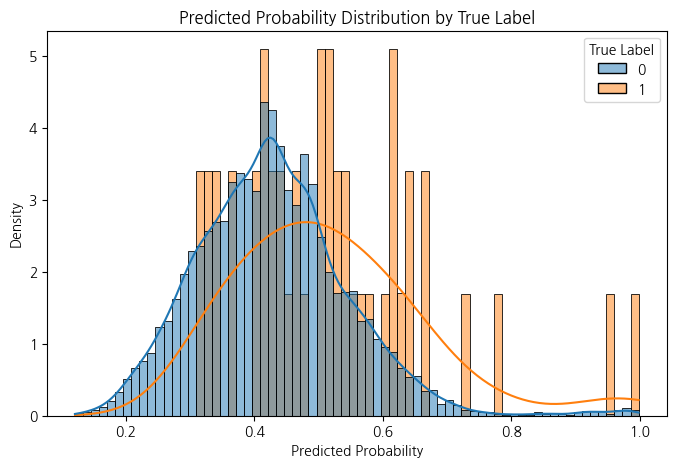

/tmp/ipykernel_12/1550169416.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=decile_labels, y=lift_deciles, palette='viridis')


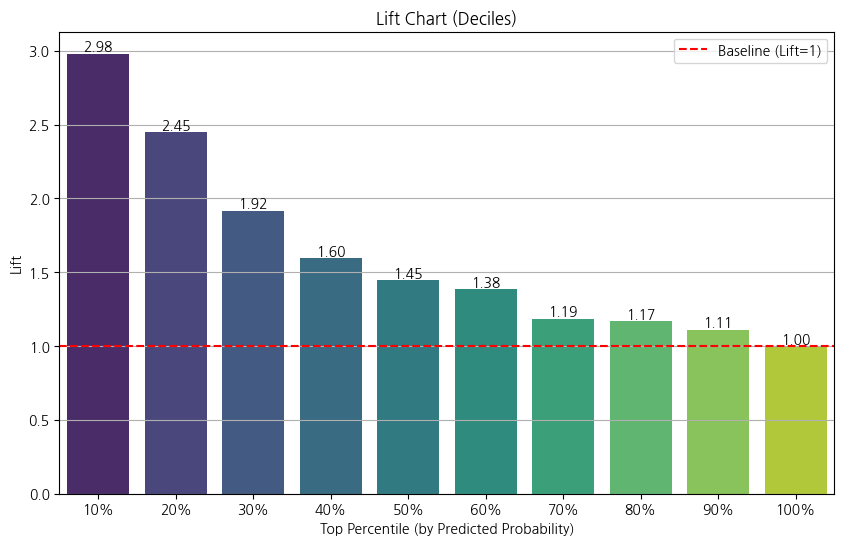

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, fbeta_score
)
from sklearn.calibration import calibration_curve

# === 한글 폰트 적용 (영역 M, 식약처 보고서 시각화용) ===
try:
    from font_helper import setup_korean_font
    setup_korean_font()
except Exception:
    import platform
    _system = platform.system()
    if _system == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif _system == 'Darwin':
        plt.rcParams['font.family'] = 'AppleGothic'
    else:
        plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    print(f"[font] Korean font set inline ({plt.rcParams['font.family']})")


print("\n" + "="*60)
print("[모델 성능 시각화] ROC, PR, Threshold, Calibration, Distribution, Lift")
print("="*60)

try:
    # [DEFECT-016 fix] 출력 layer logit → y_prob 가 stale interactive 변수일 risk 봉쇄.
    # train_and_evaluate 외부 cell 진입 시 명시적 σ(z) 변환 (scipy.special.expit, numerically stable).
    # [DEFECT-026/D-033 fix] 시각화 6 figure 모두 holdout test 기준 산출 — D-001 fix 의 val/test 분리
    # 의미가 시각화/보고 layer 에서도 유지됨 (val 위에서 평가하면 best_th_f2 결정 + early stopping monitor
    # 와 동일 set → over-optimistic). y_test / X_ts_test / X_tab_test 가 main() globals scope 에
    # 살아있음 (D-001 9-tuple unpack, cell[25] L760-765).
    from scipy.special import expit as _sigmoid
    y_prob = _sigmoid(model.predict({'ts_input': X_ts_test, 'tab_input': X_tab_test}).ravel())

    # 1) ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)'); plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve')
    plt.legend(loc="lower right"); plt.grid(True); plt.show()

    # 2) PR
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    average_precision = average_precision_score(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, color='blue', lw=2,
             label=f'PR (AP={average_precision:.3f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left"); plt.grid(True); plt.show()

    # 3) Threshold vs F2 (M-01: F1 제거)
    # [DEFECT-023 fix] 검색 grid (find_optimal_threshold) 와 axis 일치 (linspace 99점 통일).
    thresholds = np.linspace(0.01, 0.99, 99)
    recalls, precisions, f2s = [], [], []
    for th in thresholds:
        pred = (y_prob >= th).astype(int)
        recalls.append(recall_score(y_test, pred, zero_division=0))
        precisions.append(precision_score(y_test, pred, zero_division=0))
        f2s.append(fbeta_score(y_test, pred, beta=2, zero_division=0))

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, recalls, label='Recall', marker='o')
    plt.plot(thresholds, precisions, label='Precision', marker='s')
    plt.plot(thresholds, f2s, label='F2 (operational metric)', marker='v', linewidth=2)
    plt.xlabel('Decision Threshold'); plt.ylabel('Metric Value')
    plt.title('Metrics vs. Threshold (F2 only)')
    plt.legend(); plt.grid(True); plt.show()

    # 4) Calibration
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_prob, n_bins=10)
    plt.figure(figsize=(6, 5))
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Hybrid Model")
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")
    plt.xlabel("Mean Predicted Probability"); plt.ylabel("Fraction of Positives")
    plt.title("Calibration Curve")
    plt.legend(loc="lower right"); plt.grid(True); plt.show()

    # 5) Distribution of predicted probability
    plot_df = pd.DataFrame({'Predicted Probability': y_prob, 'True Label': y_test})
    plt.figure(figsize=(8, 5))
    sns.histplot(data=plot_df, x='Predicted Probability', hue='True Label', kde=True,
                 stat='density', common_norm=False)
    plt.title('Predicted Probability Distribution by True Label')
    plt.xlabel('Predicted Probability'); plt.ylabel('Density')
    plt.show()

    # 6) Lift Chart
    lift_df = pd.DataFrame({'true': y_test, 'prob': y_prob})
    lift_df = lift_df.sort_values(by='prob', ascending=False).reset_index(drop=True)
    lift_df['cumulative_true'] = lift_df['true'].cumsum()
    lift_df['cumulative_instances'] = lift_df.index + 1
    lift_df['percent_instances'] = lift_df['cumulative_instances'] / len(lift_df)
    total_positives = lift_df['true'].sum()
    baseline_positive_rate = total_positives / len(lift_df) if len(lift_df) > 0 else 0

    lift_deciles, decile_labels = [], []
    for i in range(1, 11):
        threshold_percent = i * 0.1
        decile_data = lift_df.iloc[:int(len(lift_df) * threshold_percent)]
        if not decile_data.empty:
            group_positive_rate = decile_data['true'].mean()
            decile_lift = group_positive_rate / baseline_positive_rate if baseline_positive_rate > 0 else 0
            lift_deciles.append(decile_lift)
        else:
            lift_deciles.append(0)
        decile_labels.append(f'{i*10}%')

    plt.figure(figsize=(10, 6))
    bars = sns.barplot(x=decile_labels, y=lift_deciles, palette='viridis')
    plt.axhline(1, color='red', linestyle='--', label='Baseline (Lift=1)')
    plt.xlabel('Top Percentile (by Predicted Probability)')
    plt.ylabel('Lift')
    plt.title('Lift Chart (Deciles)')
    plt.legend(); plt.grid(axis='y')
    for bar in bars.patches:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')
    plt.show()

except NameError as e:
    print(f"[오류] {e}")
    print("앞 모델링 셀이 먼저 실행되어 y_test, y_prob 가 정의되어 있어야 합니다.")
except Exception as e:
    print(f"[오류] 시각화 중 알 수 없는 예외: {e}")


In [23]:
# === [run logging] 논문 reproducibility 용 metric/메타데이터 JSON dump ===
# 저장 위치: 환경변수 RUN_LOG_DIR (Modal 컨테이너에서는 /work/outputs 로 주입). 없으면 ./_run_logs/.
import json
import os
import platform
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

OUT_DIR = Path(os.environ.get("RUN_LOG_DIR", "_run_logs"))
OUT_DIR.mkdir(parents=True, exist_ok=True)


def _to_py(x):
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, np.ndarray):
        return x.tolist()
    return x


def _safe(name, default=None):
    return globals().get(name, default)


# 1) 학습 history
hist_obj = _safe("history")
if hist_obj is None:
    m = _safe("model")
    hist_obj = getattr(m, "history", None) if m is not None else None
history_json = {}
if hist_obj is not None and hasattr(hist_obj, "history"):
    for k, vs in hist_obj.history.items():
        history_json[k] = [_to_py(v) for v in vs]

# 2) split info
split_info = {}
for name in ["y_train", "y_val", "y_test"]:
    y = _safe(name)
    if y is not None:
        arr = np.asarray(y)
        tag = name[2:]
        split_info[f"n_{tag}"] = int(len(arr))
        split_info[f"pos_{tag}"] = int(arr.sum())
        split_info[f"pos_ratio_{tag}"] = float(arr.mean())

# 3) test metric (y_prob 은 직전 시각화 셀에서 만들어 둠)
metrics = {}
y_test_g = _safe("y_test")
y_prob_g = _safe("y_prob")
best_th = _safe("best_th_f2")
if y_test_g is not None and y_prob_g is not None and best_th is not None:
    best_th_f = float(best_th)
    y_pred = (np.asarray(y_prob_g) >= best_th_f).astype(int)
    metrics = {
        "best_th_f2_from_val": best_th_f,
        "test": {
            "roc_auc": float(roc_auc_score(y_test_g, y_prob_g)),
            "pr_auc": float(average_precision_score(y_test_g, y_prob_g)),
            "f2_at_best_th": float(fbeta_score(y_test_g, y_pred, beta=2, zero_division=0)),
            "f1_at_best_th": float(f1_score(y_test_g, y_pred, zero_division=0)),
            "precision_at_best_th": float(precision_score(y_test_g, y_pred, zero_division=0)),
            "recall_at_best_th": float(recall_score(y_test_g, y_pred, zero_division=0)),
            "accuracy_at_best_th": float(accuracy_score(y_test_g, y_pred)),
            "confusion_matrix": confusion_matrix(y_test_g, y_pred).tolist(),
        },
    }
    val_f2 = _safe("best_score_f2_val")
    if val_f2 is not None:
        metrics["val"] = {"f2_at_best_th": float(val_f2)}

# 4) threshold curve (시각화 셀이 만든 변수 재사용)
threshold_curve = {}
ths = _safe("thresholds")
ps = _safe("precisions")
rs = _safe("recalls")
fs = _safe("f2s")
if all(v is not None for v in (ths, ps, rs, fs)):
    threshold_curve = {
        "thresholds": [_to_py(t) for t in ths],
        "precisions": [_to_py(p) for p in ps],
        "recalls": [_to_py(r) for r in rs],
        "f2s": [_to_py(f) for f in fs],
    }


def _nvsmi():
    try:
        return subprocess.run(
            ["nvidia-smi"], capture_output=True, text=True, check=False
        ).stdout
    except FileNotFoundError:
        return "(no nvidia-smi)"


env_meta = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "host": {"platform": platform.platform(), "python": platform.python_version()},
    "env_vars": {
        k: os.environ.get(k, "")
        for k in ["PYTHONHASHSEED", "TF_DETERMINISTIC_OPS", "TF_CUDNN_DETERMINISTIC"]
    },
    "nvidia_smi": _nvsmi(),
}

run_log = {
    "env_meta": env_meta,
    "split_info": split_info,
    "history": history_json,
    "metrics": metrics,
    "threshold_curve": threshold_curve,
}
out_path = OUT_DIR / "run_metrics.json"
out_path.write_text(json.dumps(run_log, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"[ok] run_metrics.json saved: {out_path} ({out_path.stat().st_size:,} bytes)")
n_epochs = len(next(iter(history_json.values()), []))
print(f"    history epochs : {n_epochs}")
print(f"    test ROC-AUC   : {metrics.get('test', {}).get('roc_auc', 'n/a')}")
print(f"    best_th_f2     : {metrics.get('best_th_f2_from_val', 'n/a')}")


[ok] run_metrics.json saved: /work/outputs/EXP-006_enhanced_tabular/run_metrics.json (12,029 bytes)
    history epochs : 0
    test ROC-AUC   : 0.6827382482281239
    best_th_f2     : 0.7300000190734863
